<a href="https://colab.research.google.com/github/jasonenkristo123/AIML-Learn/blob/main/sentiment_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import csv
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report


drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
csv_path = '/content/drive/MyDrive/sentiment movie/imdbmovie.csv'

df = pd.read_csv(csv_path, skip_blank_lines=True, quoting=csv.QUOTE_MINIMAL, on_bad_lines='skip')

print("Preview Dataset")
print(df.head(3))

print("\nData info")
df.info()

print("\nDistribusi Sentiment")
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts(normalize=True))

print("\nMissing value check n duplicates")
print(f"Missing value: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
  df.drop_duplicates().reset_index(drop=True)
  print(f"Ukuran Sekarang: {df.shape}")


HTML_REGEX = re.compile(r'<[^>]+>')
NON_ALPHA_REGEX = re.compile(r'[^a-z\s]')
MULTIPLE_SPACE_REGEX = re.compile(r'\s+')

def clean_text(text):
  if not isinstance(text, str):
    return ""

  text = text.lower()
  text = HTML_REGEX.sub(" ", text)
  text = NON_ALPHA_REGEX.sub(" ", text)
  text = MULTIPLE_SPACE_REGEX.sub(" ", text).strip()

  return text;


df['clean_review'] = df['review'].apply(clean_text)

print("Perbandingan sebelum clean dan sesudah\n")

sample_index = 0;
print(f"Sebelum: \n{df['review'].iloc[sample_index][:200]}...\n")
print(f"Sesudah: \n{df['clean_review'].iloc[sample_index][:200]}...\n")

Preview Dataset
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Distribusi Sentiment
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Missing value check n duplicates
Missing value: 0
Duplicates: 418
Ukuran Sekarang: (50000, 2)
Perbandingan sebelum clean dan sesudah

Sebelum: 
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The fir

LABEL ENCODING
  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
DISTRIBUSI PANJANG KALIMAT BUAT CARI RATA


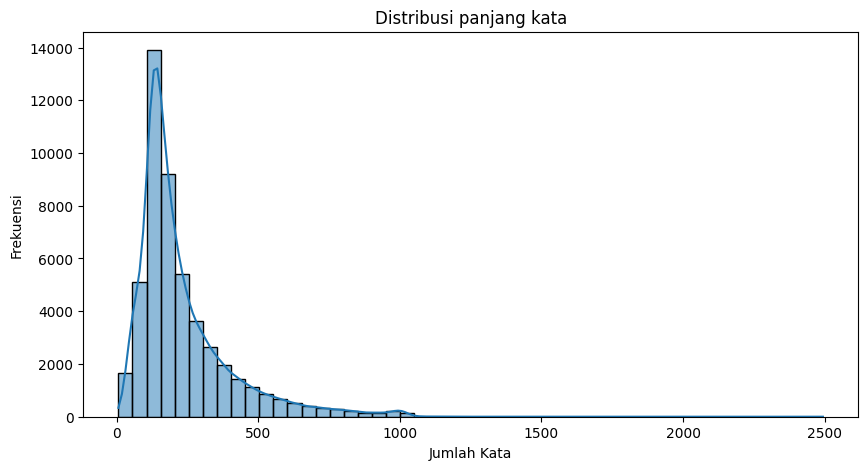

Rata-rata panjang kata: 234 Kata
Kata terpanjang: 2494
TRAIN TEST SPLIT
Data train: 40000 baris
Data test: 10000 baris
FEATURE ENGINEERING
Shape dari tfidf train (40000, 5000)

TRAINING MODEL BASELINE PAKE LOGISTIC REGRESSION
Evaluasi Model
Akurasi: 89.49%

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



In [3]:
print("LABEL ENCODING")

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df[['sentiment', 'label']].head(5))

print("DISTRIBUSI PANJANG KALIMAT BUAT CARI RATA")
df['word_count'] = df['clean_review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.title("Distribusi panjang kata")
sns.histplot(df['word_count'], bins=50, kde=True)
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

print(f"Rata-rata panjang kata: {df['word_count'].mean():.0f} Kata")
print(f"Kata terpanjang: {df['word_count'].max()}")

print("TRAIN TEST SPLIT")
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print(f"Data train: {X_train.shape[0]} baris")
print(f"Data test: {X_test.shape[0]} baris")

print("FEATURE ENGINEERING")
# kita ambil 5000 biar ga berat
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Shape dari tfidf train {X_train_tfidf.shape}")

print("\nTRAINING MODEL BASELINE PAKE LOGISTIC REGRESSION")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_predict = model.predict(X_test_tfidf)

print("Evaluasi Model")
print(f"Akurasi: {accuracy_score(y_test, y_pred=y_predict) * 100:.2f}%\n")
print(classification_report(y_test, y_pred=y_predict, target_names=['negative', 'positive']))


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

print("BUILDING VOCABULARY")
MAX_VOCAB = 10000
MAX_LEN = 250

word_counts = Counter()

for text in X_train:
  word_counts.update(str(text).split())

vocab = {word: i + 2 for i, (word, _) in enumerate(word_counts.most_common(MAX_VOCAB))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Ukuran vocabulary: {len(vocab)}")

def text_to_sequence(text, vocab, max_len):
  tokens = str(text).split()

  seq = [vocab.get(word, vocab['<UNK>']) for word in tokens]

  if len(seq) > max_len:
    seq = seq[:max_len]
  else:
    seq += [vocab['<PAD>']] * (max_len - len(seq))

  return seq

class IMDBDataset(Dataset):
  def __init__(self, texts, labels, vocab, max_len):
    self.texts = texts
    self.labels = labels
    self.vocab = vocab
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    # Menggunakan .iloc agar mengambil data berdasarkan urutan/posisi, bukan label index pandas
    text = self.texts.iloc[idx]
    label = self.labels.iloc[idx]

    seq = text_to_sequence(text, self.vocab, self.max_len)

    return torch.tensor(seq, dtype=torch.long), torch.tensor(label, dtype=torch.float32)

print("\nDATA LOADER")
train_dataset = IMDBDataset(X_train, y_train, vocab, MAX_LEN)
test_dataset = IMDBDataset(X_test, y_test, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\nUJI COBA DATALOADER")
sample_seqs, sample_label = next(iter(train_loader))
print(f"Seq_shape: {sample_seqs.shape}")
print(f"Label_shape: {sample_label.shape}")
print(f"Preview 10 angka pertama: \n{sample_seqs[0][:10].numpy()}")

BUILDING VOCABULARY
Ukuran vocabulary: 10002

DATA LOADER

UJI COBA DATALOADER
Seq_shape: torch.Size([32, 250])
Label_shape: torch.Size([32])
Preview 10 angka pertama: 
[ 11   7 141   4 244   3 158  16 532 430]
